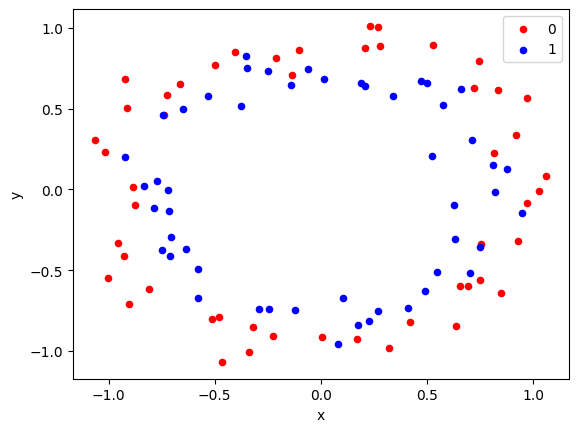

In [1]:
#Źródło: https://machinelearningmastery.com/how-to-reduce-overfitting-with-dropout-regularization-in-keras/

# generate two circles dataset
from sklearn.datasets import make_circles
from keras.layers import Dense, Input, Dropout
from keras.models import Sequential
from matplotlib import pyplot
from pandas import DataFrame

# generate 2d classification dataset
X, y = make_circles(n_samples=100, noise=0.1, random_state=1)

# scatter plot, dots colored by class value
df = DataFrame(dict(x=X[:,0], y=X[:,1], label=y))
colors = {0:'red', 1:'blue'}
fig, ax = pyplot.subplots()
grouped = df.groupby('label')
for key, group in grouped:
    group.plot(ax=ax, kind='scatter', x='x', y='y', label=key, color=colors[key])
pyplot.show()

In [2]:
# split into train and test
n_train = 30
trainX, testX = X[:n_train, :], X[n_train:, :]
trainy, testy = y[:n_train], y[n_train:]

Epoch 1/2000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.4333 - loss: 0.7019 - val_accuracy: 0.5143 - val_loss: 0.6901
Epoch 2/2000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.4667 - loss: 0.6940 - val_accuracy: 0.5143 - val_loss: 0.6923
Epoch 3/2000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.4667 - loss: 0.6875 - val_accuracy: 0.4714 - val_loss: 0.6949
Epoch 4/2000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5667 - loss: 0.6810 - val_accuracy: 0.4429 - val_loss: 0.6968
Epoch 5/2000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6000 - loss: 0.6776 - val_accuracy: 0.4571 - val_loss: 0.6997
Epoch 6/2000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6000 - loss: 0.6736 - val_accuracy: 0.4571 - val_loss: 0.7023
Epoch 7/2000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6000 - loss: 0.6693 - val_accuracy: 0.4714 - val_loss: 0.7051
Epoch 8/2000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5667 - loss: 0.6665 - val_accuracy: 0.4714 - va

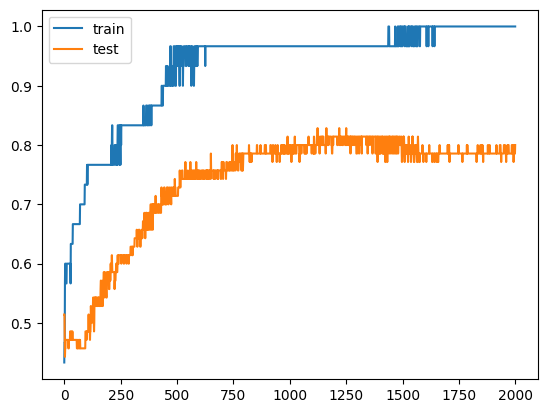

In [3]:
# define model (overfitting)
model = Sequential()
model.add(Input(shape=(trainX.shape[1],)))
model.add(Dense(500, activation='relu'))
model.add(Dense(1, activation='sigmoid'))
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

# fit model
history = model.fit(trainX, trainy, batch_size=8, validation_data=(testX, testy), epochs=2000, verbose=1)

# evaluate the model
_, train_acc = model.evaluate(trainX, trainy, verbose=0)
_, test_acc = model.evaluate(testX, testy, verbose=0)
print('Train: %.3f, Test: %.3f' % (train_acc, test_acc))

# plot history
pyplot.plot(history.history['accuracy'], label='train')
pyplot.plot(history.history['val_accuracy'], label='test')
pyplot.legend()
pyplot.show()

Epoch 1/2000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.5333 - loss: 0.6939 - val_accuracy: 0.4286 - val_loss: 0.6962
Epoch 2/2000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.5333 - loss: 0.6869 - val_accuracy: 0.4714 - val_loss: 0.6985
Epoch 3/2000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5667 - loss: 0.6801 - val_accuracy: 0.4571 - val_loss: 0.7010
Epoch 4/2000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6667 - loss: 0.6694 - val_accuracy: 0.4714 - val_loss: 0.7037
Epoch 5/2000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5667 - loss: 0.6806 - val_accuracy: 0.4429 - val_loss: 0.7066
Epoch 6/2000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6000 - loss: 0.6718 - val_accuracy: 0.4286 - val_loss: 0.7096
Epoch 7/2000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5667 - loss: 0.6676 - val_accuracy: 0.4286 - val_loss: 0.7119
Epoch 8/2000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5667 - loss: 0.6656 - val_accuracy: 0.4143 - v

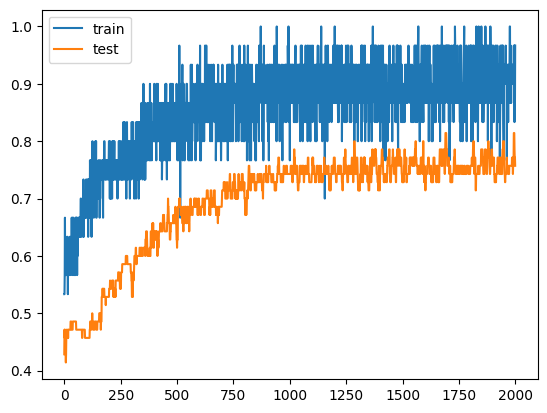

In [4]:
# define model with dropout
model = Sequential()
model.add(Input(shape=(trainX.shape[1],)))
model.add(Dense(500, activation='relu'))
model.add(Dropout(0.4))
model.add(Dense(1, activation='sigmoid'))
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

# fit model
history = model.fit(trainX, trainy, batch_size=8, validation_data=(testX, testy), epochs=2000, verbose=1)

# evaluate the model
_, train_acc = model.evaluate(trainX, trainy, verbose=0)
_, test_acc = model.evaluate(testX, testy, verbose=0)
print('Train: %.3f, Test: %.3f' % (train_acc, test_acc))

# plot history
pyplot.plot(history.history['accuracy'], label='train')
pyplot.plot(history.history['val_accuracy'], label='test')
pyplot.legend()
pyplot.show()